In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
# import ssl

#ssl._create_default_https_context = ssl._create_unverified_context
plt.rcParams['figure.figsize'] = 14, 6

In [2]:
normalize_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./CIFAR10/train", train=True, transform=normalize_transform, download=True)
test_dataset = torchvision.datasets.CIFAR10(
    root="./CIFAR10/test", train=False, transform=normalize_transform, download=True)

100.0%
100.0%


In [3]:
batch_size = 128
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size)

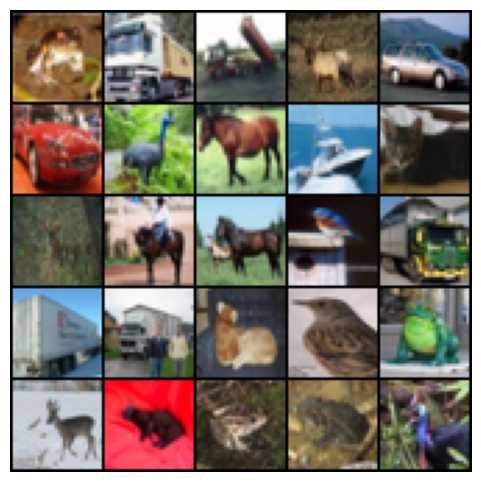

In [4]:
dataiter = iter(train_loader)
images, labels = next(dataiter)
plt.imshow(np.transpose(torchvision.utils.make_grid(
    images[:25], normalize=True, padding=1, nrow=5).numpy(), (1, 2, 0)))
plt.axis('off')
plt.show()

In [5]:
class CNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.model = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=3, out_channels=32,
                            kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),
            torch.nn.Conv2d(in_channels=32, out_channels=64,
                            kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),
            torch.nn.Conv2d(in_channels=64, out_channels=64,
                            kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),
            torch.nn.Flatten(),
            torch.nn.Linear(64 * 4 * 4, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.model(x)

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = CNN()#.to(device)

num_epochs = 10
learning_rate = 0.001
weight_decay = 0.01
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(), lr=learning_rate, weight_decay=weight_decay)

In [7]:
train_loss_list = []
for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}:', end=' ')
    train_loss = 0
    model.train()
    for images, labels in train_loader:
        #images = images.to(device)
        #labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss_list.append(train_loss / len(train_loader))
    print(f"Training loss = {train_loss_list[-1]}")

Epoch 1/10: Training loss = 1.6583007400298058
Epoch 2/10: Training loss = 1.3985351406399855
Epoch 3/10: Training loss = 1.2754762948626448
Epoch 4/10: Training loss = 1.1814374603578806
Epoch 5/10: Training loss = 1.1168509519008725
Epoch 6/10: 

KeyboardInterrupt: 

In [9]:
print(train_loss_list)

[1.6583007400298058, 1.3985351406399855, 1.2754762948626448, 1.1814374603578806, 1.1168509519008725]


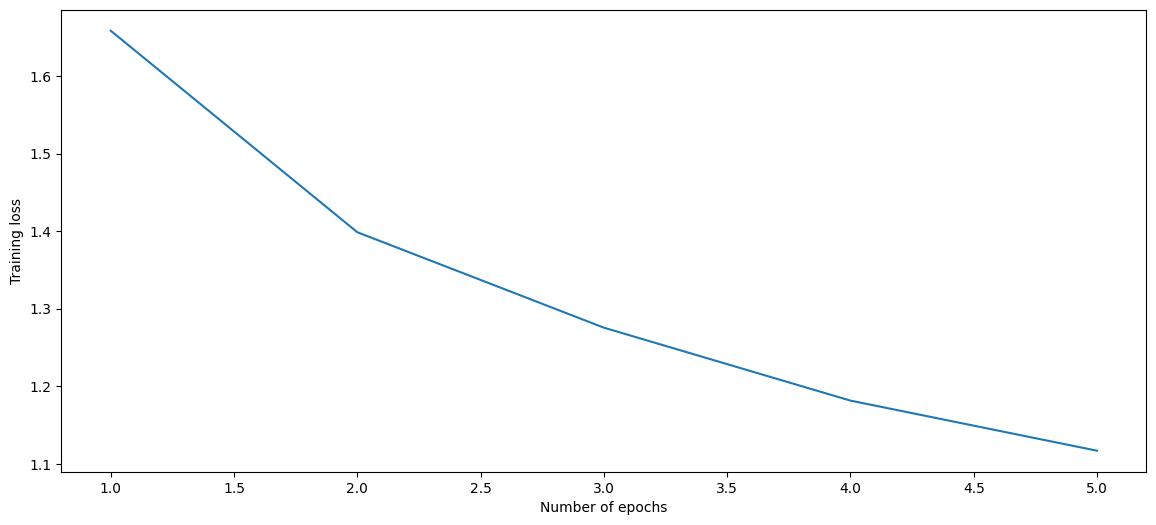

In [12]:
plt.plot(range(1, 5 + 1), train_loss_list)
plt.xlabel("Number of epochs")
plt.ylabel("Training loss")
plt.show()

In [14]:
test_acc = 0
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images#.to(device)
        y_true = labels#.to(device)
        outputs = model(images)
        _, y_pred = torch.max(outputs.data, 1)
        test_acc += (y_pred == y_true).sum().item()

print(f"Test set accuracy = {100 * test_acc / len(test_dataset)} %")

Test set accuracy = 61.34 %


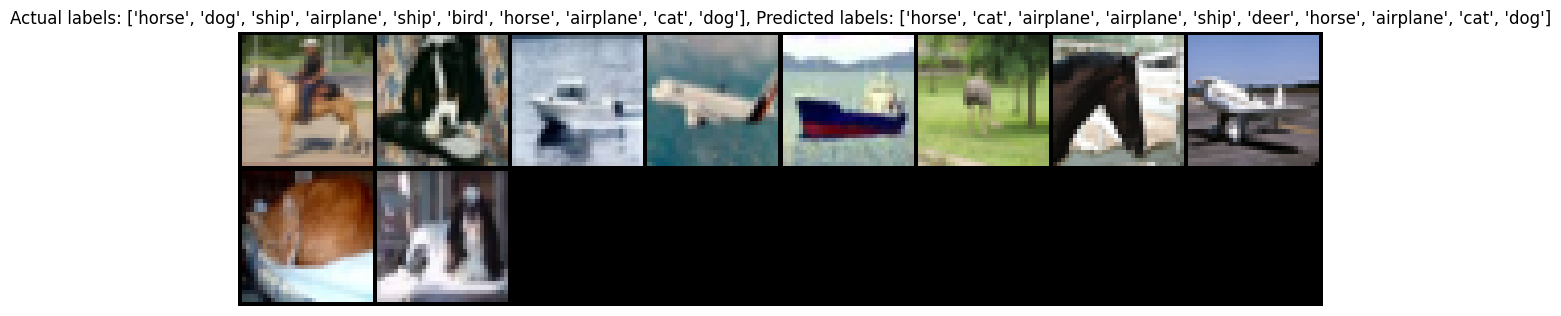

In [18]:
num_images = 10
y_true_name = [names[y_true[idx]] for idx in range(num_images)]
y_pred_name = [names[y_pred[idx]] for idx in range(num_images)]
title = f"Actual labels: {y_true_name}, Predicted labels: {y_pred_name}"

plt.imshow(np.transpose(torchvision.utils.make_grid(
    images[:num_images].cpu(), normalize=True, padding=1).numpy(), (1, 2, 0)))
plt.title(title)
plt.axis("off")
plt.show()

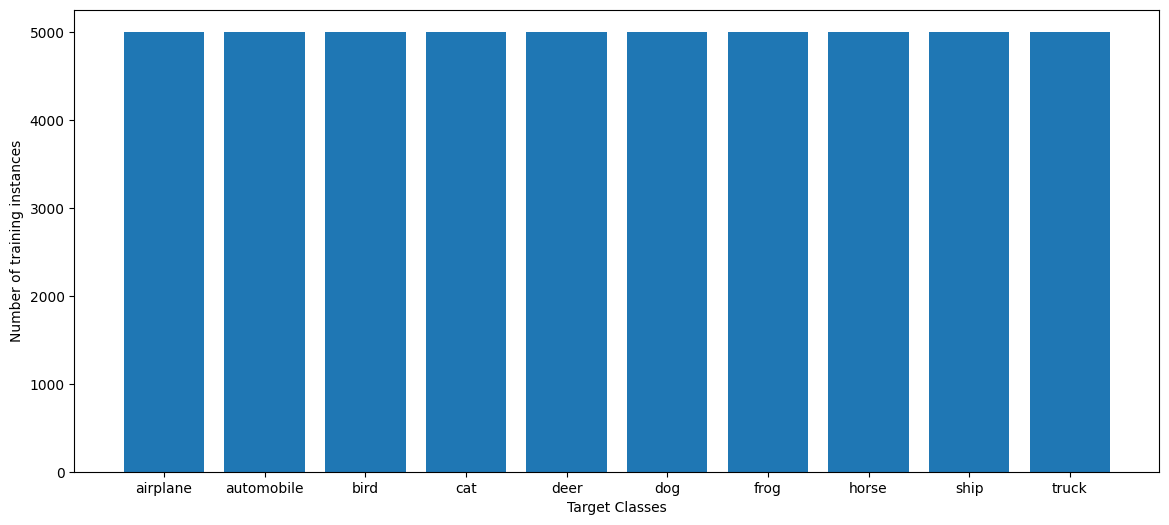

In [ ]:
classes = []
for batch_idx, data in enumerate(train_loader):
    x, y = data
    classes.extend(y.tolist())

unique, counts = np.unique(classes, return_counts=True)
names = list(test_dataset.class_to_idx.keys())
plt.bar(names, counts)
plt.xlabel("Target Classes")
plt.ylabel("Number of training instances")
plt.show()